In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.listdir('/content/drive/MyDrive/anemia_detection/datasets')

['palpablepalm_dataset.zip',
 'fingernails_dataset.zip',
 'conjunctiva_dataset.zip']

In [3]:
!unzip "/content/drive/MyDrive/anemia_detection/datasets/fingernails_dataset.zip"

Archive:  /content/drive/MyDrive/anemia_detection/datasets/fingernails_dataset.zip
  inflating: Detection of Anemia using Colour of the Fingernails Image Datasets from Ghana/Fingernails.rar  


In [4]:
!unrar x "/content/Detection of Anemia using Colour of the Fingernails Image Datasets from Ghana/Fingernails.rar"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/Detection of Anemia using Colour of the Fingernails Image Datasets from Ghana/Fingernails.rar

Creating    Fingernails                                               OK
Extracting  Fingernails/Anemic-Fin-007 (10).png                            0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (11).png                            0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (12).png                            0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (2).png                             0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (3).png                             0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (4).png                             0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (5).png                             0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (6).png                             0% 

In [5]:
import os

os.listdir('/content')
dataset_path = "/content/Fingernails"
from glob import glob

images = glob(dataset_path + "/*.png")

print("Toplam görüntü:", len(images))
print(images[:5])

Toplam görüntü: 4260
['/content/Fingernails/Non-Anrmic-FN-144 (7).png', '/content/Fingernails/Non-Anrmic-FN-148 (5).png', '/content/Fingernails/Non-Anrmic-FN-177 (12).png', '/content/Fingernails/Anemic-FN-258 (2).png', '/content/Fingernails/Non-Anrmic-FN-192 (5).png']


In [6]:
import os
from glob import glob

images = glob(dataset_path + "/*")

print("Toplam bulunan dosya:", len(images))
for x in images[:10]:
    print(repr(os.path.basename(x)))

Toplam bulunan dosya: 4260
'Non-Anrmic-FN-144 (7).png'
'Non-Anrmic-FN-148 (5).png'
'Non-Anrmic-FN-177 (12).png'
'Anemic-FN-258 (2).png'
'Non-Anrmic-FN-192 (5).png'
'Non-Anrmic-FN-048 (5).png'
'Anemic-FN-239.png'
'Anemic-Fin-020 (6).png'
'Anemic-FN-033 (11).png'
'Non-anemic-Fin-013.png'


In [7]:
import os
import re
import pandas as pd
from glob import glob

files = glob(os.path.join(dataset_path, "*.png"))

def parse_filename(path):
    name = os.path.basename(path)
    stem = os.path.splitext(name)[0]

    # augmentation numarası
    aug_match = re.search(r"\((\d+)\)$", stem)
    if aug_match:
        aug_no = int(aug_match.group(1))
        stem_core = re.sub(r"\s*\(\d+\)$", "", stem)
    else:
        aug_no = 1
        stem_core = stem

    lower = stem_core.lower()

    # sınıf
    if lower.startswith("non-anemic"):
        cls = "Non-Anemic"
        rest = stem_core[len("Non-Anemic-"):] if stem_core.startswith("Non-Anemic-") else stem_core[len("Non-anemic-"):]
    elif lower.startswith("anemic"):
        cls = "Anemic"
        rest = stem_core[len("Anemic-"):]
    else:
        cls = "Unknown"
        rest = stem_core

    # subtype
    subtype = "base"
    if rest.endswith("FV"):
        subtype = "FV"
        rest = rest[:-2]
    elif rest.endswith("RA"):
        subtype = "RA"
        rest = rest[:-2]
    elif "Conj-" in rest:
        subtype = "Conj"
        rest = rest.replace("Conj-", "")
    elif "Con-" in rest:
        subtype = "Con"
        rest = rest.replace("Con-", "")

    # id yakala
    id_match = re.search(r"(\d+)", rest)
    sample_id = id_match.group(1) if id_match else None

    series_key = f"{cls}_{sample_id}_{subtype}"

    return {
        "filename": name,
        "class": cls,
        "sample_id": sample_id,
        "subtype": subtype,
        "aug_no": aug_no,
        "series_key": series_key,
        "path": path
    }

df = pd.DataFrame([parse_filename(f) for f in files])

print(df.head(20))
print("\nSubtype sayıları:")
print(df["subtype"].value_counts())

print("\nSeri sayıları:")
print(df["series_key"].nunique())

print("\nHer seride kaç görüntü var:")
print(df.groupby("series_key").size().value_counts().sort_index())

                      filename       class sample_id subtype  aug_no  \
0    Non-Anrmic-FN-144 (7).png     Unknown       144    base       7   
1    Non-Anrmic-FN-148 (5).png     Unknown       148    base       5   
2   Non-Anrmic-FN-177 (12).png     Unknown       177    base      12   
3        Anemic-FN-258 (2).png      Anemic       258    base       2   
4    Non-Anrmic-FN-192 (5).png     Unknown       192    base       5   
5    Non-Anrmic-FN-048 (5).png     Unknown       048    base       5   
6            Anemic-FN-239.png      Anemic       239    base       1   
7       Anemic-Fin-020 (6).png      Anemic       020    base       6   
8       Anemic-FN-033 (11).png      Anemic       033    base      11   
9       Non-anemic-Fin-013.png  Non-Anemic       013    base       1   
10   Non-Anrmic-FN-201 (4).png     Unknown       201    base       4   
11   Non-Anrmic-FN-102 (4).png     Unknown       102    base       4   
12   Non-Anrmic-FN-033 (6).png     Unknown       033    base    

In [8]:
anemic_count = (
    df["filename"].str.startswith("Anemic").sum()
    + df["filename"].str.startswith("Anmeic").sum()
)
non_anemic_count = (
    df["filename"].str.startswith("Non-Anemic").sum()
    + df["filename"].str.startswith("Non-Anrmic").sum()
    + df["filename"].str.startswith("Non-anemic").sum()
)

print("Anemic ile başlayan:", anemic_count)
print("Non-anemic ile başlayan:", non_anemic_count)
print("Toplam:", anemic_count + non_anemic_count)

Anemic ile başlayan: 2565
Non-anemic ile başlayan: 1695
Toplam: 4260


In [9]:
# Tüm prefixler
prefixes = ["Anemic", "Non-Anemic", "Non-Anrmic", "Non-anemic"]

# Bu prefixlerle başlamayan dosyaları seç
other_files = df[~df["filename"].str.startswith(tuple(prefixes))]

# Kaç tane dosya var
print("Diğer dosya sayısı:", len(other_files))

# Dosya isimlerini görmek istersen
print(other_files["filename"].tolist())

Diğer dosya sayısı: 44
['Anmeic-fn-009 (2).png', 'Anmeic-fn-0011 2.png', 'Anmeic-fn-0023.png', 'Anmeic-fn-005 2.png', 'Anmeic-fn-008 1.png', 'Anmeic-fn-004.png', 'Anmeic-fn-005.png', 'Anmeic-fn-001 1.png', 'Anmeic-fn-0001.png', 'Anmeic-fn-009.png', 'Anmeic-fn-0021.png', 'Anmeic-fn-003 1.png', 'Anmeic-fn-001.png', 'Anmeic-fn-0001 1.png', 'Anmeic-fn-008.png', 'Anmeic-fn-004 1 5.png', 'Anmeic-fn-0021 1 5.png', 'Anmeic-fn-0012.png', 'Anmeic-fn-0013.png', 'Anmeic-fn-007.png', 'Anmeic-fn-00214.png', 'Anmeic-fn-008 12.png', 'Anmeic-fn-00134.png', 'Anmeic-fn-002 1.png', 'Anmeic-fn-0011.png', 'Anmeic-fn-0012 2.png', 'Anmeic-fn-0023 2.png', 'Anmeic-fn-0011 (2).png', 'Anmeic-fn-009 1 (2).png', 'Anmeic-fn-003.png', 'Anmeic-fn-006.png', 'Anmeic-fn-007 2.png', 'Anmeic-fn-006 1.png', 'Anmeic-fn-0012 2 (2).png', 'Anmeic-fn-0011 2 (2).png', 'Anmeic-fn-002.png', 'Anmeic-fn-004 1 1.png', 'Anmeic-fn-00131.png', 'Anmeic-fn-009 1.png', 'Anmeic-fn-004 14.png', 'Anmeic-fn-004 1.png', 'Anmeic-fn-0021 1.png', '

In [10]:
import cv2
import numpy as np

# Tüm veriyi kullan
df_exp = df.copy()

print("Kullanılan veri sayısı:", len(df_exp))
print(df_exp["subtype"].value_counts())
print(df_exp["class"].value_counts())

groups = []
features = []
labels = []

for _, row in df_exp.iterrows():
    img = cv2.imread(row["path"])
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    H, S, V = cv2.split(hsv)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    L, a, b = cv2.split(lab)

    R_mean = np.mean(R)
    G_mean = np.mean(G)
    B_mean = np.mean(B)

    features.append([
        # RGB mean/std
        np.mean(R), np.std(R),
        np.mean(G), np.std(G),
        np.mean(B), np.std(B),

        # LAB mean/std
        np.mean(L), np.std(L),
        np.mean(a), np.std(a),
        np.mean(b), np.std(b),

        # HSV mean/std
        np.mean(H), np.std(H),
        np.mean(S), np.std(S),
        np.mean(V), np.std(V),

        # Percentiles
        np.percentile(R, 25), np.percentile(R, 50), np.percentile(R, 75),
        np.percentile(G, 25), np.percentile(G, 50), np.percentile(G, 75),
        np.percentile(B, 25), np.percentile(B, 50), np.percentile(B, 75),

        # Color ratios
        R_mean / (G_mean + 1e-6),
        R_mean / (B_mean + 1e-6),
        G_mean / (B_mean + 1e-6),
        R_mean / (R_mean + G_mean + B_mean + 1e-6),
        G_mean / (R_mean + G_mean + B_mean + 1e-6),
        B_mean / (R_mean + G_mean + B_mean + 1e-6),

        # Gray texture basics
        np.mean(gray),
        np.std(gray),
        np.var(gray)
    ])

    labels.append(1 if row["class"] == "Anemic" else 0)
    groups.append(row["series_key"])

X = np.array(features, dtype=np.float32)
y = np.array(labels, dtype=np.int32)
groups = np.array(groups)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sınıf dağılımı:", np.bincount(y))
print("İlk 5 feature:\n", X[:10])
print("İlk 5 label:\n", y[:10])

Kullanılan veri sayısı: 4260
subtype
base    4226
FV        17
RA        17
Name: count, dtype: int64
class
Anemic        2521
Unknown       1625
Non-Anemic     114
Name: count, dtype: int64
X shape: (4260, 36)
y shape: (4260,)
Sınıf dağılımı: [1739 2521]
İlk 5 feature:
 [[1.50538040e+02 8.57291336e+01 1.40752533e+02 8.04185333e+01
  1.32030075e+02 7.55030441e+01 1.47271378e+02 8.38405228e+01
  1.29991669e+02 1.61501205e+00 1.33683701e+02 3.42586422e+00
  1.09152174e+01 6.39865685e+00 2.39318848e+01 1.48095789e+01
  1.50538040e+02 8.57291336e+01 1.62750000e+02 1.93000000e+02
  2.08000000e+02 1.46000000e+02 1.79000000e+02 1.97000000e+02
  1.36000000e+02 1.68000000e+02 1.85000000e+02 1.06952274e+00
  1.14017999e+00 1.06606424e+00 3.55612338e-01 3.32496256e-01
  3.11891407e-01 1.42678268e+02 8.14262924e+01 6.63024121e+03]
 [1.55553238e+02 8.27693939e+01 1.46900970e+02 7.92489319e+01
  1.35752899e+02 7.49142532e+01 1.53073578e+02 8.20568924e+01
  1.29263489e+02 2.60091710e+00 1.34838470e+0

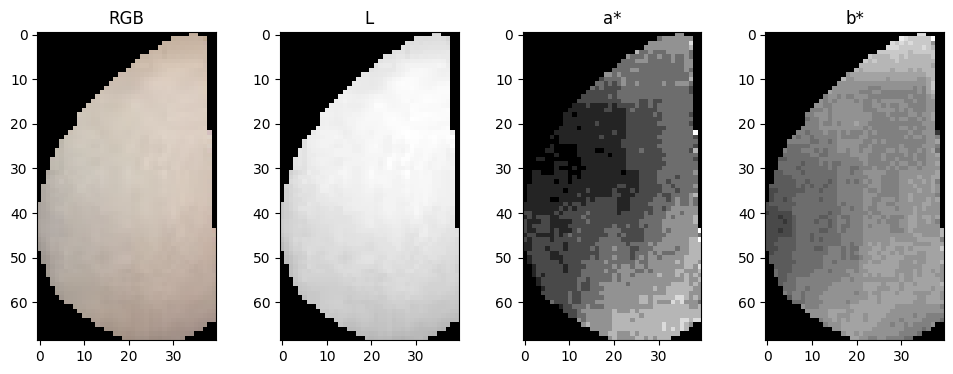

In [11]:
import matplotlib.pyplot as plt

row = df_exp.iloc[0]

img = cv2.imread(row["path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

L,a,b = cv2.split(lab)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("RGB")

plt.subplot(1,4,2)
plt.imshow(L,cmap="gray")
plt.title("L")

plt.subplot(1,4,3)
plt.imshow(a,cmap="gray")
plt.title("a*")

plt.subplot(1,4,4)
plt.imshow(b,cmap="gray")
plt.title("b*")

plt.show()

In [12]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3327, 36)
Test: (933, 36)


In [13]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "Naive Bayes": GaussianNB(var_smoothing=1e-1),
    "SVM": SVC(
    kernel="rbf",
    C=10,
    gamma="auto",
    probability=True,
    random_state=42
),
    "KNN": KNeighborsClassifier(n_neighbors=1),
    "Decision Tree": DecisionTreeClassifier(
    criterion='gini',       # veya 'entropy' – bilgi kazancına göre bölme
    max_depth=35,         # Ağacın maksimum derinliği, overfitting’i engellemek için sınır koyabilirsin
    min_samples_split=2,    # Dallanmak için gereken minimum örnek sayısı
    min_samples_leaf=2,     # Yaprakta bulunacak minimum örnek sayısı
    max_features=2,      # Bölmede kullanılacak maksimum özellik sayısı
    random_state=42
),
    "Gradient Boosting": GradientBoostingClassifier(
    n_estimators=500,        # Kaç ağaç kullanılacağı, default 100. Daha fazla → genellikle daha iyi performans
    learning_rate=0.5,      # Her ağacın katkısı, default 0.1. Küçük değer → daha stabil öğrenme
    max_depth=3,             # Ağaç derinliği, default 3. Daha derin → overfitting riski
    min_samples_split=2,     # Dallanma için minimum örnek sayısı
    min_samples_leaf=1,      # Yaprak başına minimum örnek sayısı
    subsample=0.8,           # Rastgele alt örnekleme oranı, 0.8 → overfitting azaltır
    max_features=None,       # Her ağacı oluştururken kullanılacak özellik sayısı
    random_state=42
),

  "XGBoost": XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    min_child_weight=1,
    gamma=0,
    subsample=1,
    colsample_bytree=0.95,
    reg_alpha=0,
    reg_lambda=1,
    eval_metric="logloss",
    random_state=42
),

  "CatBoost": CatBoostClassifier(
    iterations=1000,           # Kaç ağaç oluşturulacağı, default 100
    learning_rate=0.5,        # Öğrenme hızı, küçük değer → daha stabil sonuç
    depth=6,                   # Ağaç derinliği, default 6
    l2_leaf_reg=3,             # L2 regularization katsayısı
    subsample=0.8,             # Rastgele örnekleme oranı
    colsample_bylevel=0.8,     # Özellik örnekleme oranı
    verbose=0,
    random_state=42
),

  "AdaBoost": AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, min_samples_leaf=2),      # Temel öğrenici, default DecisionTreeClassifier(max_depth=1)
    n_estimators=1000,          # Kaç ağaç/estimator oluşturulacağı, default 50
    learning_rate=1,        # Her estimator’un katkı ağırlığı, default 1.0
    random_state=42
),

    "HistGradientBoosting": HistGradientBoostingClassifier(
    max_iter=100,            # Kaç boosting iterasyonu yapılacağı, default 100
    learning_rate=0.5,       # Öğrenme hızı
    max_depth=None,           # Her ağaç için maksimum derinlik, None → tam büyüme
    min_samples_leaf=20,      # Yaprak başına minimum örnek sayısı
    max_leaf_nodes=31,        # Her ağacın maksimum yaprak sayısı
    l2_regularization=0.0,    # L2 regularizasyon katsayısı
    random_state=42
)
}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


Naive Bayes
10-fold Group CV mean: 0.5630627893590349
std: 0.04422083455995998

SVM
10-fold Group CV mean: 0.5953306383957143
std: 0.03463414134962071

KNN
10-fold Group CV mean: 0.592852937010728
std: 0.08523900887371359

Decision Tree
10-fold Group CV mean: 0.5949026347422623
std: 0.050766438873850656

Gradient Boosting
10-fold Group CV mean: 0.6443915668330557
std: 0.07350097761134142

XGBoost
10-fold Group CV mean: 0.6498383037911182
std: 0.0699349404631422

CatBoost
10-fold Group CV mean: 0.659748204028731
std: 0.06241066789562274

AdaBoost
10-fold Group CV mean: 0.6713527476727819
std: 0.05051623625734557

HistGradientBoosting
10-fold Group CV mean: 0.6816124500289383
std: 0.08109357211888654


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
     "Naive Bayes": GaussianNB(var_smoothing=1e-8),

}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "SVM": SVC(
    kernel="linear",
    C=10,
    gamma="auto",
    probability=True,
    random_state=42
),

}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "HistGradientBoosting": HistGradientBoostingClassifier(
    max_iter=100,            # Kaç boosting iterasyonu yapılacağı, default 100
    learning_rate=0.5,       # Öğrenme hızı
    max_depth=None,           # Her ağaç için maksimum derinlik, None → tam büyüme
    min_samples_leaf=20,      # Yaprak başına minimum örnek sayısı
    max_leaf_nodes=3,        # Her ağacın maksimum yaprak sayısı
    l2_regularization=0.0,    # L2 regularizasyon katsayısı
    random_state=42
),
}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


HistGradientBoosting
10-fold Group CV mean: 0.6445633719368157
std: 0.1048161125490972


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # bazı modellerde predict_proba olmayabilir
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = roc_auc_score(y_test, y_pred)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Algorithm": name,
        "Accuracy": round(acc*100,4),
        "F1-score": round(f1*100,4),
        "AUC": round(auc*100,4),
        "Precision": round(prec*100,4),
        "Recall": round(rec*100,4)
    })

results_df = pd.DataFrame(results)

results_df

,Algorithm,Accuracy,F1-score,AUC,Precision,Recall
0,Naive Bayes,59.5927,74.6810,41.6245,59.5927,100.0000
1,SVM,59.6999,74.7312,53.8099,59.6567,100.0000
2,KNN,54.2337,56.1151,55.4522,65.4676,49.1007
3,Decision Tree,63.0225,68.1440,62.2285,70.0190,66.3669
4,Gradient Boosting,62.8081,68.4832,70.6687,69.1743,67.8058
5,XGBoost,70.6324,74.5826,77.4040,77.0115,72.3022
6,CatBoost,66.0236,70.0661,73.0731,73.7575,66.7266
7,AdaBoost,71.2755,75.5474,77.2895,76.6667,74.4604
8,HistGradientBoosting,73.2047,76.0077,78.3257,81.4815,71.2230


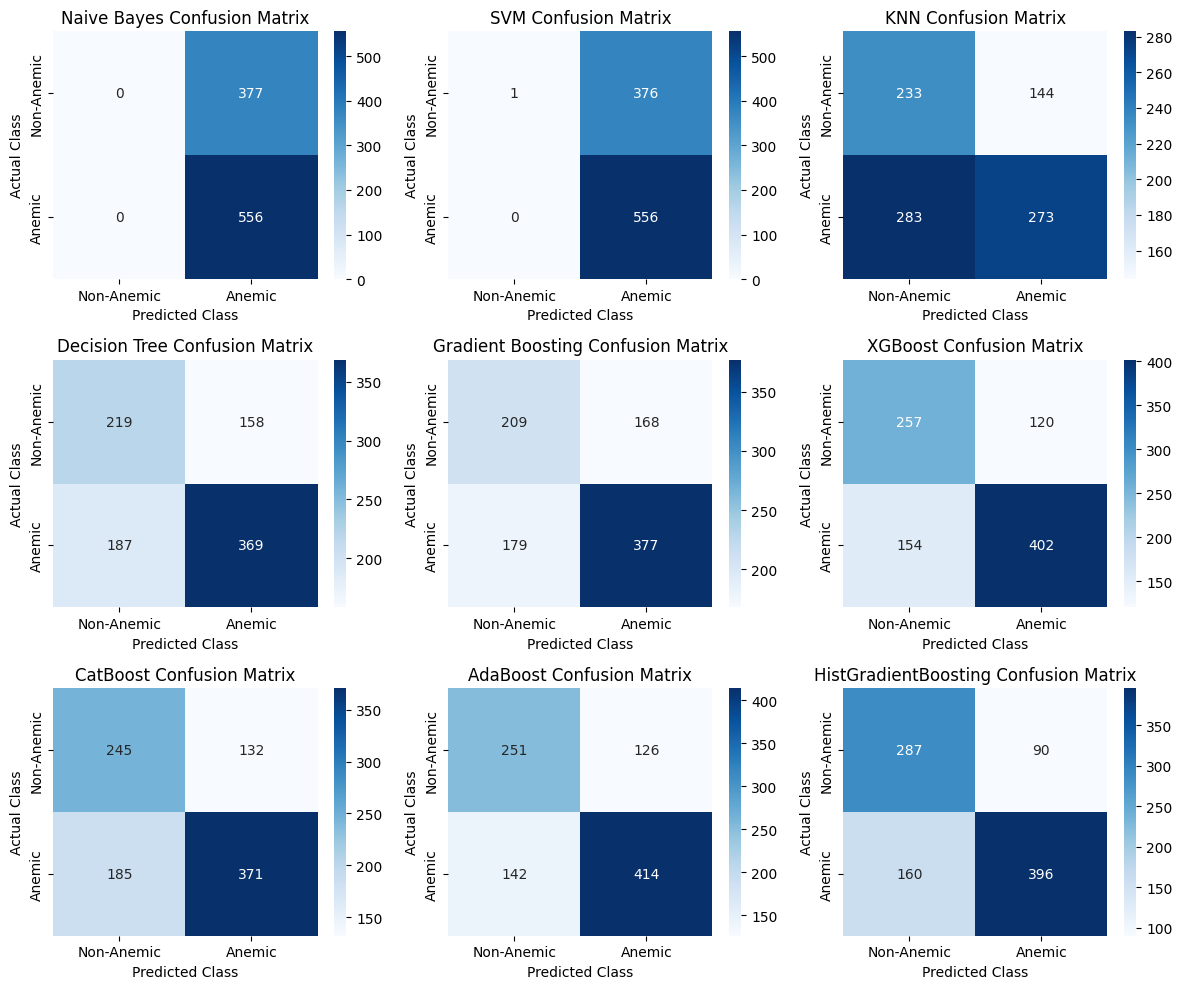

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3,3, figsize=(12,10))

axes = axes.flatten()

for i, (name,model) in enumerate(models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test,y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=["Non-Anemic","Anemic"],
        yticklabels=["Non-Anemic","Anemic"]
    )

    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted Class")
    axes[i].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

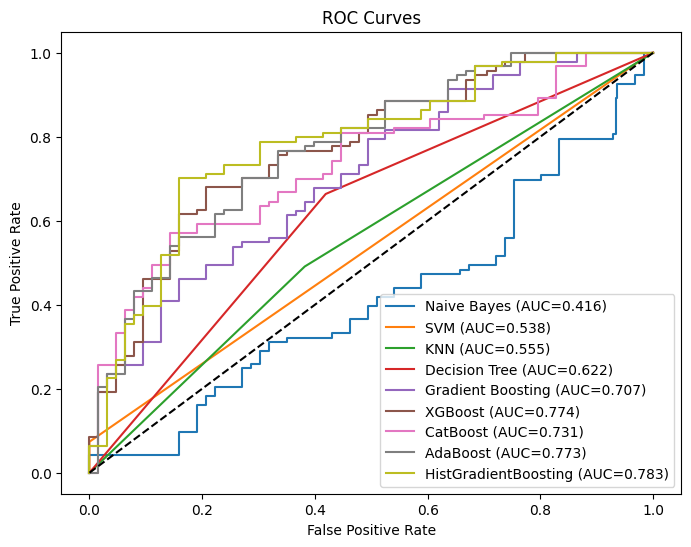

In [17]:

from sklearn.metrics import roc_curve, auc as sk_auc

plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = sk_auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [ ]:
import joblib
import os

# Kaydedilecek klasör
model_folder = "fingernails_models"
os.makedirs(model_folder, exist_ok=True)

for name, model in models.items():
    # Modeli dosyaya kaydet
    filename = os.path.join(model_folder, f"{name.replace(' ','_')}.joblib")
    joblib.dump(model, filename)
    print(f"{name} kaydedildi → {filename}")

Naive Bayes kaydedildi → fingernails_models/Naive_Bayes.joblib
SVM kaydedildi → fingernails_models/SVM.joblib
KNN kaydedildi → fingernails_models/KNN.joblib
Decision Tree kaydedildi → fingernails_models/Decision_Tree.joblib
Gradient Boosting kaydedildi → fingernails_models/Gradient_Boosting.joblib
XGBoost kaydedildi → fingernails_models/XGBoost.joblib
CatBoost kaydedildi → fingernails_models/CatBoost.joblib
AdaBoost kaydedildi → fingernails_models/AdaBoost.joblib
HistGradientBoosting kaydedildi → fingernails_models/HistGradientBoosting.joblib


In [18]:
print(np.bincount(y_train))
print(np.bincount(y_test))

[1362 1965]
[377 556]



LightGBM
10-fold Group CV mean accuracy: 0.6929392657777811
10-fold Group CV std: 0.06771813687668016
  Algorithm  Accuracy  F1-score      AUC  Precision  Recall
0  LightGBM   66.7738   71.8693  74.1837    72.5275  71.223


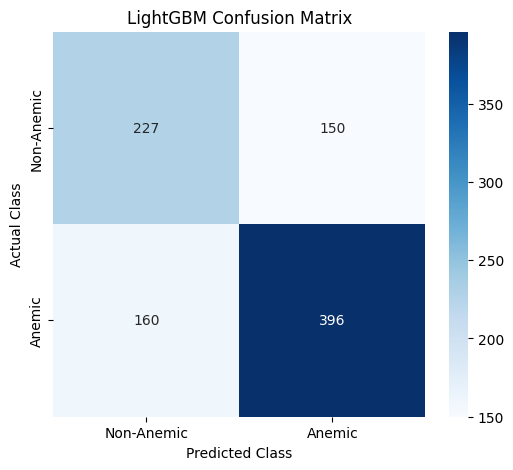

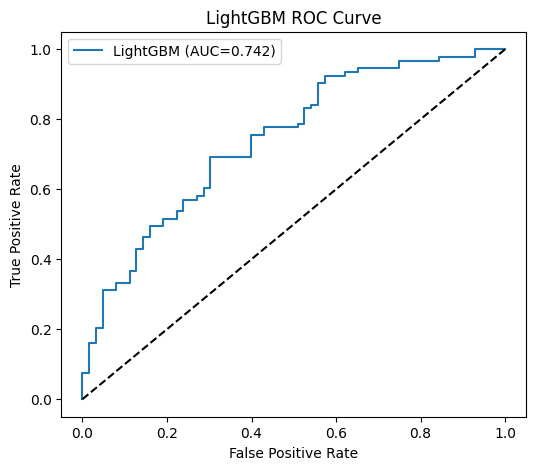

In [19]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc as sk_auc
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------
# LightGBM için dataframe (FULL FEATURE SET)
# -----------------------------------
feature_names = [
    # RGB
    "R_mean","R_std","G_mean","G_std","B_mean","B_std",

    # LAB
    "L_mean","L_std","a_mean","a_std","b_mean","b_std",

    # HSV
    "H_mean","H_std","S_mean","S_std","V_mean","V_std",

    # Percentiles RGB
    "R_p25","R_p50","R_p75",
    "G_p25","G_p50","G_p75",
    "B_p25","B_p50","B_p75",

    # Ratios
    "R_G","R_B","G_B",
    "R_ratio","G_ratio","B_ratio",

    # Gray texture
    "gray_mean","gray_std","gray_var"
]

X_train_lgb = pd.DataFrame(X_train, columns=feature_names)
X_test_lgb = pd.DataFrame(X_test, columns=feature_names)

# -----------------------------------
# LightGBM modeli
# -----------------------------------
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    verbose=-1
)

# -----------------------------------
# GROUP BASED CROSS VALIDATION
# -----------------------------------
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(
    lgb_model,
    X_train_lgb,
    y_train,
    cv=cv,
    groups=groups_train,
    scoring="accuracy"
)

print("\nLightGBM")
print("10-fold Group CV mean accuracy:", scores.mean())
print("10-fold Group CV std:", scores.std())

# -----------------------------------
# TRAIN
# -----------------------------------
lgb_model.fit(X_train_lgb, y_train)

# -----------------------------------
# TEST
# -----------------------------------
y_pred_lgb = lgb_model.predict(X_test_lgb)
y_prob_lgb = lgb_model.predict_proba(X_test_lgb)[:, 1]

# -----------------------------------
# METRICS
# -----------------------------------
acc = accuracy_score(y_test, y_pred_lgb)
prec = precision_score(y_test, y_pred_lgb)
rec = recall_score(y_test, y_pred_lgb)
f1 = f1_score(y_test, y_pred_lgb)
auc = roc_auc_score(y_test, y_prob_lgb)

results_lgb = pd.DataFrame([{
    "Algorithm": "LightGBM",
    "Accuracy": round(acc * 100, 4),
    "F1-score": round(f1 * 100, 4),
    "AUC": round(auc * 100, 4),
    "Precision": round(prec * 100, 4),
    "Recall": round(rec * 100, 4)
}])

print(results_lgb)

# -----------------------------------
# CONFUSION MATRIX
# -----------------------------------
cm = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Anemic", "Anemic"],
    yticklabels=["Non-Anemic", "Anemic"]
)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

# -----------------------------------
# ROC CURVE
# -----------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob_lgb)
roc_auc = sk_auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"LightGBM (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curve")
plt.legend()

plt.show()

In [ ]:
import joblib
import os

# Kaydedilecek klasör
model_folder = "fingernails_models"

# LightGBM modelini kaydet
filename = os.path.join(model_folder, "LightGBM_model.joblib")
joblib.dump(lgb_model, filename)
print(f"LightGBM modeli kaydedildi → {filename}")

LightGBM modeli kaydedildi → fingernails_models/LightGBM_model.joblib
